In [27]:
import numpy as np
from matplotlib import pyplot as plt

ex. 1.1

In [170]:
e = 1
while (1+e)>1:
    e = e/10
e10 = e
print(e10)

1.0000000000000001e-16


In [171]:
e = 1
while (1+e)>1:
    e = e/2
e2 = e
print(e2)

1.1102230246251565e-16


ex. 1.2

In [172]:
def n_quad_formula(a,b,c):
    x1 = (-b-np.sqrt(b**2-4*a*c))/(2*a)
    x2 = (-b+np.sqrt(b**2-4*a*c))/(2*a)
    x = np.array([x1,x2])
    return x

def s_quad_formula(a,b,c):
    x1 = (-b-np.sign(b)*np.sqrt(b**2-4*a*c))/(2*a)
    x2 = c/(a*x1)
    x = np.array([x1,x2])
    return x

In [173]:
a = 1
b = 1e8
c = 1

naive = n_quad_formula(a,b,c)
stable = s_quad_formula(a,b,c)

print(naive)
print(stable)

[-1.0000000e+08 -7.4505806e-09]
[-1.e+08 -1.e-08]


In [174]:
exact = np.array([-9.99999999999999899999999999999989999999999999997999999999999999499999999999999860000*1e7,-1.000000000000000100000000000000020000000000000005000000000000001400000000000000420000*1e-8])
n_rerr = (naive-exact)/exact
s_rerr = (stable-exact)/exact

print(n_rerr,s_rerr)

[ 1.49011612e-16 -2.54941940e-01] [ 1.49011612e-16 -0.00000000e+00]


ex. 3

In [175]:
def f(k):
    return 1+10**(-k)

In [176]:
x = []
corr = []
for k in range(1,21):
    x.append(f(k))
    corr.append(10**(-k))
x = np.array(x)
corr = np.array(corr)

[ 8.32667268e-17  8.67361738e-18 -1.10154941e-16 -1.10182046e-17
  6.55112222e-17 -8.22665927e-17  5.83867222e-17 -6.07747099e-17
  8.27403709e-17  8.27403710e-18  8.27403711e-19  8.89005823e-17
 -7.99277837e-17 -7.99277837e-18  1.10223025e-16 -1.00000000e-16
 -1.00000000e-17 -1.00000000e-18 -1.00000000e-19 -1.00000000e-20]


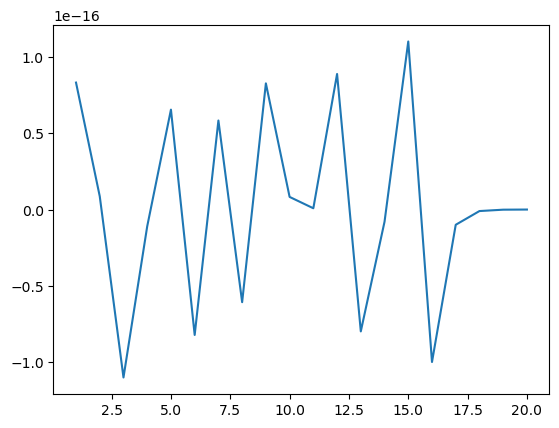

In [177]:
print((x-1-corr))
plt.plot(range(1,21),(x-1-corr))

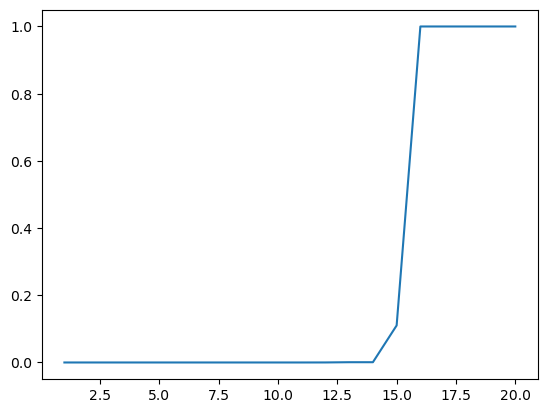

In [179]:
plt.plot(range(1,21),abs(x-1-corr)/corr)

ex. 2.1

In [180]:
def left_rectangle(func,xmin,xmax,N):
    integral = 0
    left = xmin
    step = (-xmin+xmax)/N
    for i in range(N):
        integral = integral + func(left) * step
        left = xmin + i * step
    return integral
def right_rectangle(func,xmin,xmax,N):
    integral = 0
    step = (-xmin+xmax)/N
    right = xmin+step
    for i in range(N):
        integral += func(right)*step
        right += step
    return integral
def central_rectangle(func,xmin,xmax,N):
    integral = 0
    step = (-xmin+xmax)/N
    centre = xmin + step/2
    for i in range(N):
        integral += func(centre)*step
        centre += step
    return integral

In [181]:
def trap(func,xmin,xmax,N):
    integral = 0
    step = (-xmin+xmax)/N
    left = xmin
    right = xmin+step
    step = (-xmin+xmax)/N
    for i in range(N):
        integral = integral + (func(left)+func(right))*step/2
        left = left + step
        right = right + step
    return integral

def simpson(func,xmin,xmax,N):
    integral = 0
    step = (-xmin+xmax)/N
    ai = xmin
    bi = xmin+step
    mi = (ai+bi)/2
    for i in range(N):
        integral = integral + (func(ai)+func(bi)+ 4*func(mi)) * step/6
        ai = ai + step
        bi = bi + step
        mi = mi + step
    return integral

def simpson_reverse(func,xmin,xmax,N):
    integral = 0
    step = (-xmin+xmax)/N
    ai = xmax-step
    bi = xmax
    mi = (ai+bi)/2
    for i in range(N):
        integral = integral + (func(ai)+func(bi)+ 4*func(mi)) * step/6
        ai = ai - step
        bi = bi - step
        mi = mi - step
    return integral

In [130]:
'''
def left_rectangle(func,xmin,xmax,step):
    integral = 0
    left = xmin
    for i in range(int((-xmin+xmax)/step)):
        integral = integral + func(left) * step
        left = xmin + i * step
    return integral
def right_rectangle(func,xmin,xmax,step):
    integral = 0
    right = xmin+step
    for i in range(int((xmax-xmin)/step)):
        integral += func(right)*step
        right += step
    return integral
def central_rectangle(func,xmin,xmax,step):
    integral = 0
    centre = xmin + step/2
    for i in range(int((xmax-xmin)/step)):
        integral += func(centre)*step
        centre += step
    return integral
'''

'\ndef left_rectangle(func,xmin,xmax,step):\n    integral = 0\n    left = xmin\n    for i in range(int((-xmin+xmax)/step)):\n        integral = integral + func(left) * step\n        left = xmin + i * step\n    return integral\ndef right_rectangle(func,xmin,xmax,step):\n    integral = 0\n    right = xmin+step\n    for i in range(int((xmax-xmin)/step)):\n        integral += func(right)*step\n        right += step\n    return integral\ndef central_rectangle(func,xmin,xmax,step):\n    integral = 0\n    centre = xmin + step/2\n    for i in range(int((xmax-xmin)/step)):\n        integral += func(centre)*step\n        centre += step\n    return integral\n'

In [182]:
# for a pl

In [183]:
integral = left_rectangle((lambda x : x**2), 0, 1, 512) 
print(integral)

integral = right_rectangle((lambda x : x**2), 0, 1, 512) 
print(integral)

integral = central_rectangle((lambda x : x**2), 0, 1, 512) 
print(integral)

0.3304119035601616
0.33431053161621094
0.33333301544189453


In [184]:
# for an exponential

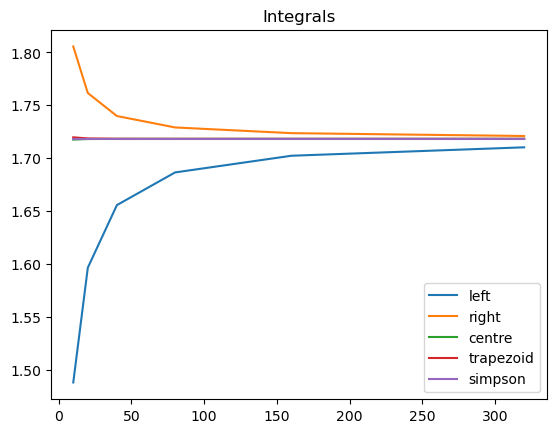

In [185]:
integral_l=[]
integral_r=[]
integral_c=[]
integral_t=[]
integral_s=[]
N = [10, 20, 40, 80, 160, 320]
for i in [10, 20, 40, 80, 160, 320]:
    integral = left_rectangle((lambda x : np.exp(x)), 0, 1, i) 
    integral_l.append(integral)
    
    integral = right_rectangle((lambda x : np.exp(x)), 0, 1, i) 
    integral_r.append(integral)
    
    integral = central_rectangle((lambda x : np.exp(x)), 0, 1, i) 
    integral_c.append(integral)

    integral = trap((lambda x : np.exp(x)), 0, 1, i) 
    integral_t.append(integral)
    
    integral = simpson((lambda x : np.exp(x)), 0, 1, i) 
    integral_s.append(integral)

plt.plot([10, 20, 40, 80, 160, 320],integral_l,label='left')
plt.plot([10, 20, 40, 80, 160, 320],integral_r,label='right')
plt.plot([10, 20, 40, 80, 160, 320],integral_c,label='centre')
plt.plot([10, 20, 40, 80, 160, 320],integral_t,label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],integral_s,label='simpson')
plt.title('Integrals')
plt.legend()

[]

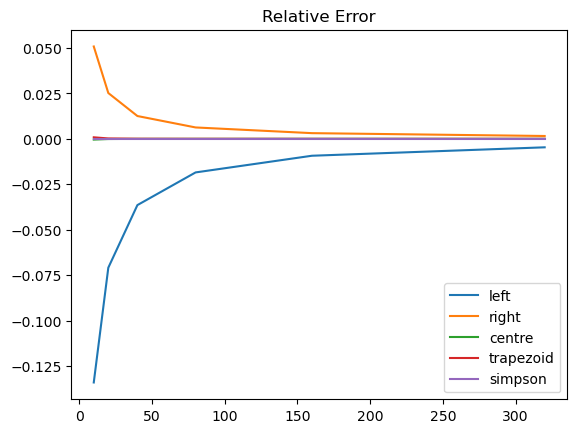

In [186]:
plt.plot([10, 20, 40, 80, 160, 320],(integral_l-np.exp(1)+1)/(np.exp(1)-1),label='left')
plt.plot([10, 20, 40, 80, 160, 320],(integral_r-np.exp(1)+1)/(np.exp(1)-1),label='right')
plt.plot([10, 20, 40, 80, 160, 320],(integral_c-np.exp(1)+1)/(np.exp(1)-1),label='centre')
plt.plot([10, 20, 40, 80, 160, 320],(integral_t-np.exp(1)+1)/(np.exp(1)-1),label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],(integral_s-np.exp(1)+1)/(np.exp(1)-1),label='simpson')
plt.legend()
plt.title('Relative Error')
plt.plot()

[]

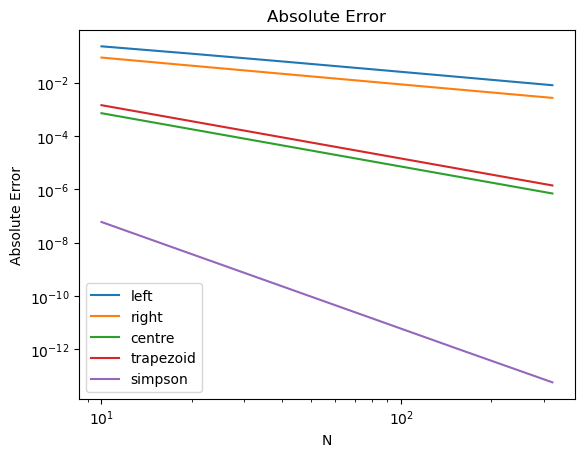

In [187]:
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_l-np.exp(1)+1),label='left')
#plt.scatter([10, 20, 40, 80, 160, 320],abs(integral_l-np.exp(1)+1),label='left')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_r-np.exp(1)+1),label='right')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_c-np.exp(1)+1),label='centre')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_t-np.exp(1)+1),label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_s-np.exp(1)+1),label='simpson')
plt.xlabel('N')
plt.ylabel('Absolute Error')
plt.xscale('log')
plt.yscale('log')
plt.title('Absolute Error')
plt.legend()
plt.plot()


In [188]:
import scipy

In [189]:
p_l = scipy.stats.linregress(np.log(N), np.log(abs(integral_l-np.exp(1)+1)))[0]
print(p_l) #atteso -1
p_r = scipy.stats.linregress(np.log(N), np.log(abs(integral_r-np.exp(1)+1)))[0]
print(p_r) #atteso -1
p_c = scipy.stats.linregress(np.log(N), np.log(abs(integral_c-np.exp(1)+1)))[0]
print(p_c) #atteso -2
p_t = scipy.stats.linregress(np.log(N), np.log(abs(integral_t-np.exp(1)+1)))[0]
print(p_t) #atteso -2
p_s = scipy.stats.linregress(np.log(N), np.log(abs(integral_s-np.exp(1)+1)))[0]
print(p_s) #atteso -4

-0.971032908446031
-1.0042818435959415
-1.9999305147336464
-1.9999602948433877
-3.9964153225902166


In [190]:
# for f4

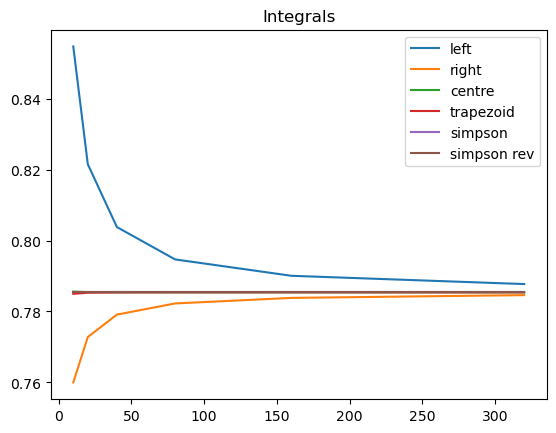

In [191]:
integral_l=[]
integral_r=[]
integral_c=[]
integral_t=[]
integral_s=[]
integral_sr=[]
N = [10, 20, 40, 80, 160, 320]
for i in [10, 20, 40, 80, 160, 320]:
    integral = left_rectangle((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_l.append(integral)
    
    integral = right_rectangle((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_r.append(integral)
    
    integral = central_rectangle((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_c.append(integral)

    integral = trap((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_t.append(integral)
    
    integral = simpson((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_s.append(integral)

    integral = simpson((lambda x : 1/(1+x**2)), 0, 1, i) 
    integral_sr.append(integral)

plt.plot([10, 20, 40, 80, 160, 320],integral_l,label='left')
plt.plot([10, 20, 40, 80, 160, 320],integral_r,label='right')
plt.plot([10, 20, 40, 80, 160, 320],integral_c,label='centre')
plt.plot([10, 20, 40, 80, 160, 320],integral_t,label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],integral_s,label='simpson')
plt.plot([10, 20, 40, 80, 160, 320],integral_sr,label='simpson rev')
plt.title('Integrals')
plt.legend()

In [192]:
integral_l = np.array(integral_l)
integral_r = np.array(integral_r)
integral_c = np.array(integral_c)
integral_t = np.array(integral_t)
integral_s = np.array(integral_s)
integral_sr = np.array(integral_sr)

[]

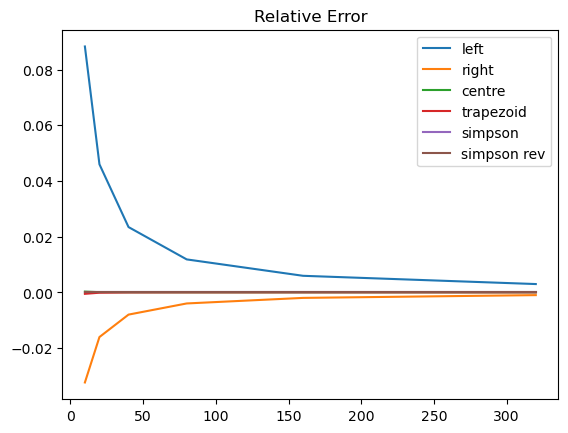

In [193]:
plt.plot([10, 20, 40, 80, 160, 320],(integral_l-np.pi/4)/(np.pi/4),label='left')
plt.plot([10, 20, 40, 80, 160, 320],(integral_r-np.pi/4)/(np.pi/4),label='right')
plt.plot([10, 20, 40, 80, 160, 320],(integral_c-np.pi/4)/(np.pi/4),label='centre')
plt.plot([10, 20, 40, 80, 160, 320],(integral_t-np.pi/4)/(np.pi/4),label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],(integral_s-np.pi/4)/(np.pi/4),label='simpson')
plt.plot([10, 20, 40, 80, 160, 320],(integral_sr-np.pi/4)/(np.pi/4),label='simpson rev')

plt.legend()
plt.title('Relative Error')
plt.plot()

[]

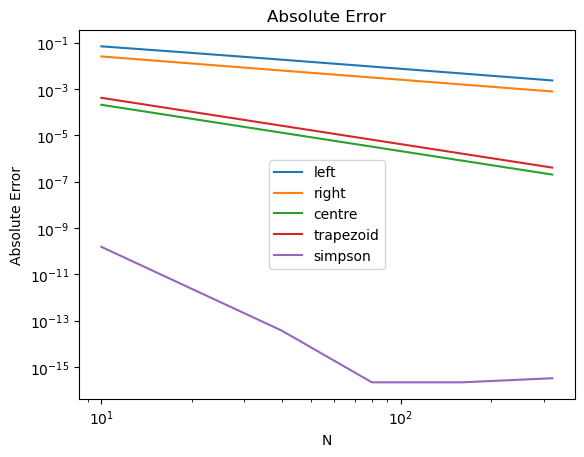

In [194]:
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_l-np.pi/4),label='left')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_r-np.pi/4),label='right')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_c-np.pi/4),label='centre')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_t-np.pi/4),label='trapezoid')
plt.plot([10, 20, 40, 80, 160, 320],abs(integral_s-np.pi/4),label='simpson')
#plt.plot([10, 20, 40, 80, 160, 320],abs(integral_sr-np.pi/4),label='simpson rev')

plt.xlabel('N')
plt.ylabel('Absolute Error')
plt.xscale('log')
plt.yscale('log')
plt.title('Absolute Error')
plt.legend()
plt.plot()


# perché simpson è molto più steep

In [195]:
p_l = scipy.stats.linregress(np.log(N), np.log(abs(integral_l-np.pi/4)))[0]
print(p_l) #atteso -1
p_r = scipy.stats.linregress(np.log(N), np.log(abs(integral_r-np.pi/4)))[0]
print(p_r) #atteso -1
p_c = scipy.stats.linregress(np.log(N), np.log(abs(integral_c-np.pi/4)))[0]
print(p_c) #atteso -2
p_t = scipy.stats.linregress(np.log(N), np.log(abs(integral_t-np.pi/4)))[0]
print(p_t) #atteso -2
p_s = scipy.stats.linregress(np.log(N[:-2]), np.log(abs(integral_s[:-2]-np.pi/4)))[0]
print(p_s) #atteso -4 --> viene molto più ripido!

-0.9798011531808148
-1.0042824465139533
-1.9999995070552874
-1.9999997451586797
-6.423848901513475


ex. 4.1

In [196]:
def f4(x):
    return x**3-2*x-5

In [197]:
xtrue = 2.0946
epsilon = 1e-3
xguess = 10